# Tox21 Drug Toxicity Prediction

এই notebook-টা researcher-style end-to-end workflow: **data loading → chemical cleaning → missing label masking → feature engineering → 70/10/20 train/validation/test split → 12 models → evaluation → leaderboard → final saving**।

Target problem: **Tox21 multi-label binary toxicity classification**।

## 0. Environment setup

RDKit লাগবে molecular features বানানোর জন্য। Colab/Kaggle-এ missing package থাকলে নিচের install line uncomment করে run করবে।

In [79]:
# Colab/Kaggle এ দরকার হলে uncomment করো:
# !pip -q install rdkit-pypi xgboost lightgbm iterative-stratification imbalanced-learn

## 1. Import libraries

এখানে reproducibility, data handling, ML, plotting এবং model saving libraries import করা হলো।

In [80]:
import os
import math
import json
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
print("Section-1 is okay")

Section-1 is okay


In [81]:
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import BernoulliNB
import joblib
print("Section-2 is okay")

Section-2 is okay


In [82]:
try:
    from rdkit import Chem
    from rdkit.Chem import AllChem, MACCSkeys, Descriptors, rdMolDescriptors
    from rdkit.Chem.MolStandardize import rdMolStandardize
    RDKIT_AVAILABLE = True
except Exception as e:
    RDKIT_AVAILABLE = False
    print("RDKit import failed:", e)

from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

In [83]:
try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
    ITERSTRAT_AVAILABLE = True
except Exception:
    ITERSTRAT_AVAILABLE = False
    print("iterative-stratification package not found. Random split fallback will be used.")
print("Section-4 is okay")

Section-4 is okay


In [84]:
try:
    from imblearn.ensemble import BalancedRandomForestClassifier
    IMBLEARN_AVAILABLE = True
except Exception:
    IMBLEARN_AVAILABLE = False
    print("imbalanced-learn not found. RandomForest with class_weight fallback will be used.")
print("Section-5 is okay")

Section-5 is okay


In [85]:
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False
    print("XGBoost not found. XGBoost block will be skipped.")

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except Exception:
    LGBM_AVAILABLE = False
    print("LightGBM not found. LightGBM block will be skipped.")

## 2. Global configuration

সব random seed fixed রাখা হলো, যাতে split এবং model result reproducible হয়।

In [86]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

N_BITS = 2048
RADIUS = 2
TEST_SIZE = 0.20
VAL_SIZE = 0.10
TRAIN_SIZE = 0.70

# Full researcher run. Runtime বেশি হলে values কমানো যাবে।
N_ESTIMATORS = 300
DL_EPOCHS = 30
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
PATIENCE = 6

RESULT_DIR = Path("tox21_outputs")
RESULT_DIR.mkdir(exist_ok=True)
print("Section-7 is okay")

Section-7 is okay


## 3. Load Tox21 dataset

Notebook একই folder-এ `tox21.csv` খুঁজবে। এই environment-এ uploaded file `/mnt/data/tox21.csv` থেকেও load করতে পারবে।

In [87]:
possible_paths = [Path("tox21.csv"), Path("/mnt/data/tox21.csv")]
DATA_PATH = next((p for p in possible_paths if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError("tox21.csv পাওয়া যায়নি। Notebook-এর পাশে tox21.csv রাখো।")

print("Using dataset:", DATA_PATH)
df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)
df_raw.head()

Using dataset: tox21.csv
Raw shape: (7831, 14)


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [88]:
TARGET_COLS = [c for c in df_raw.columns if c not in ["mol_id", "smiles"]]
print("Number of toxicity endpoints:", len(TARGET_COLS))
print(TARGET_COLS)

Number of toxicity endpoints: 12
['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']


In [89]:
# Labels numeric করা হচ্ছে। Missing labels NaN হিসেবেই থাকবে।
for col in TARGET_COLS:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

missing_cells = int(df_raw[TARGET_COLS].isna().sum().sum())
total_label_cells = int(df_raw[TARGET_COLS].size)
print("Missing label cells:", missing_cells)
print("Missing %:", round(100 * missing_cells / total_label_cells, 2))

Missing label cells: 16026
Missing %: 17.05


## 4. Quick EDA: missing labels and imbalance

Tox21 imbalanced dataset। তাই accuracy main metric হবে না; ROC-AUC, PR-AUC, MCC, Balanced Accuracy, F1 use করবো।

In [90]:
balance_rows = []
for col in TARGET_COLS:
    y = df_raw[col].dropna().astype(int)
    pos = int((y == 1).sum())
    neg = int((y == 0).sum())
    balance_rows.append({
        "endpoint": col,
        "observed": len(y),
        "missing": int(df_raw[col].isna().sum()),
        "positive": pos,
        "negative": neg,
        "positive_%": 100 * pos / max(len(y), 1),
        "neg_pos_ratio": neg / max(pos, 1),
    })

balance_df = pd.DataFrame(balance_rows).sort_values("positive_%")
balance_df

,endpoint,observed,missing,positive,negative,positive_%,neg_pos_ratio
6,NR-PPAR-gamma,6450,1381,186,6264,2.883721,33.677419
1,NR-AR-LBD,6758,1073,237,6521,3.506955,27.514768
8,SR-ATAD5,7072,759,264,6808,3.733032,25.787879
0,NR-AR,7265,566,309,6956,4.253269,22.511327
5,NR-ER-LBD,6955,876,350,6605,5.032351,18.871429
3,NR-Aromatase,5821,2010,300,5521,5.153754,18.403333
9,SR-HSE,6467,1364,372,6095,5.752281,16.384409
11,SR-p53,6774,1057,423,6351,6.244464,15.014184
2,NR-AhR,6549,1282,768,5781,11.726981,7.527344
4,NR-ER,6193,1638,793,5400,12.804780,6.809584


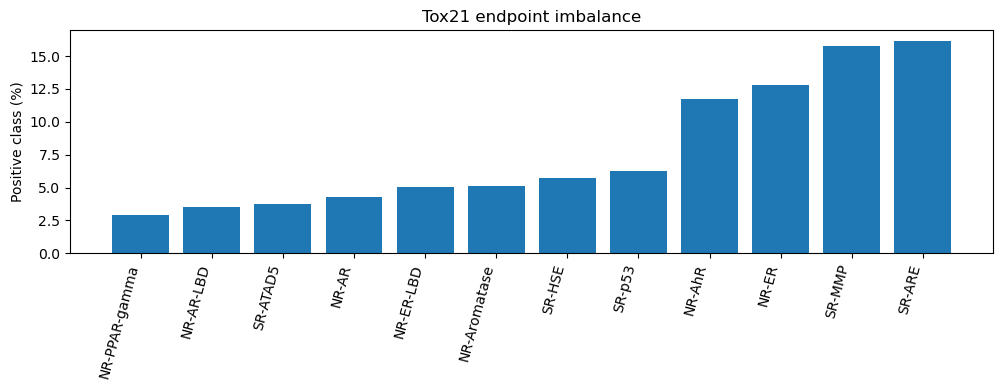

In [91]:
plt.figure(figsize=(10, 4))
plt.bar(balance_df["endpoint"], balance_df["positive_%"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("Positive class (%)")
plt.title("Tox21 endpoint imbalance")
plt.tight_layout()
plt.show()

## 5. Chemical preprocessing

Research-quality cleaning: invalid SMILES remove, largest fragment choose, normalize, uncharge, canonical SMILES generate।

In [92]:
if not RDKIT_AVAILABLE:
    raise ImportError("RDKit দরকার। Install করে notebook আবার run করো।")

normalizer = rdMolStandardize.Normalizer()
fragment_chooser = rdMolStandardize.LargestFragmentChooser()
uncharger = rdMolStandardize.Uncharger()
print("Okay")

Okay


In [93]:
def standardize_smiles(smiles):
    # SMILES থেকে standardized RDKit Mol ও canonical SMILES return করে।
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return None, None
        mol = fragment_chooser.choose(mol)
        mol = normalizer.normalize(mol)
        mol = uncharger.uncharge(mol)
        Chem.SanitizeMol(mol)
        can = Chem.MolToSmiles(mol, canonical=True)
        return mol, can
    except Exception:
        return None, None
    

In [94]:
clean_records = []
invalid_ids = []

for idx, row in df_raw.iterrows():
    mol, can = standardize_smiles(row["smiles"])
    if mol is None:
        invalid_ids.append(idx)
        continue
    rec = row.to_dict()
    rec["mol"] = mol
    rec["clean_smiles"] = can
    clean_records.append(rec)

df = pd.DataFrame(clean_records).reset_index(drop=True)
print("Invalid SMILES removed:", len(invalid_ids))
print("Clean shape:", df.shape)

Invalid SMILES removed: 9
Clean shape: (7822, 16)


In [95]:
# Duplicate canonical SMILES থাকলে merge/drop করা হবে। এই dataset-এ সাধারণত duplicate নেই।
dup_count = int(df["clean_smiles"].duplicated().sum())
print("Duplicate canonical SMILES:", dup_count)

if dup_count > 0:
    df = df.drop_duplicates("clean_smiles", keep="first").reset_index(drop=True)
    print("After duplicate drop:", df.shape)

Duplicate canonical SMILES: 211
After duplicate drop: (7611, 16)


## 6. Feature engineering

Classic ML-এর জন্য Morgan fingerprint + MACCS + RDKit physicochemical descriptors বানানো হলো।

In [96]:
def mol_to_morgan_fp(mol, radius=RADIUS, n_bits=N_BITS):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.int8)
    Chem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

In [97]:
def mol_to_maccs(mol):
    fp = MACCSkeys.GenMACCSKeys(mol)
    arr = np.zeros((167,), dtype=np.int8)
    Chem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

In [98]:
SELECTED_DESCRIPTORS = [
    "MolWt", "MolLogP", "TPSA", "NumHDonors", "NumHAcceptors",
    "NumRotatableBonds", "RingCount", "HeavyAtomCount", "FractionCSP3",
    "NHOHCount", "NOCount", "NumAromaticRings", "NumAliphaticRings",
]

def compute_rdkit_descriptors(mol):
    return {
        "MolWt": Descriptors.MolWt(mol),
        "MolLogP": Descriptors.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "NumHDonors": rdMolDescriptors.CalcNumHBD(mol),
        "NumHAcceptors": rdMolDescriptors.CalcNumHBA(mol),
        "NumRotatableBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "RingCount": rdMolDescriptors.CalcNumRings(mol),
        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "NHOHCount": Descriptors.NHOHCount(mol),
        "NOCount": Descriptors.NOCount(mol),
        "NumAromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "NumAliphaticRings": rdMolDescriptors.CalcNumAliphaticRings(mol),
    }

In [99]:
X_morgan = np.vstack([mol_to_morgan_fp(m) for m in df["mol"]]).astype(np.float32)
X_maccs = np.vstack([mol_to_maccs(m) for m in df["mol"]]).astype(np.float32)
desc_df = pd.DataFrame([compute_rdkit_descriptors(m) for m in df["mol"]])

print("Morgan:", X_morgan.shape)
print("MACCS:", X_maccs.shape)
print("Descriptors:", desc_df.shape)

Morgan: (7611, 2048)
MACCS: (7611, 167)
Descriptors: (7611, 13)


## 7. Train / Validation / Test split: 70 / 10 / 20

Leakage avoid করতে split আগে করা হলো। Iterative multilabel stratification থাকলে সেটা use হবে, না হলে random fallback।

In [100]:
y_all = df[TARGET_COLS].astype("float32")
Y_split = y_all.fillna(0).astype(int).values
indices = np.arange(len(df))

if ITERSTRAT_AVAILABLE:
    splitter1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=(VAL_SIZE + TEST_SIZE), random_state=SEED)
    train_idx, temp_idx = next(splitter1.split(indices, Y_split))

    temp_y = Y_split[temp_idx]
    splitter2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE), random_state=SEED)
    val_rel_idx, test_rel_idx = next(splitter2.split(temp_idx, temp_y))
    val_idx = temp_idx[val_rel_idx]
    test_idx = temp_idx[test_rel_idx]
    split_method = "iterative_multilabel_stratified"
else:
    train_idx, temp_idx = train_test_split(indices, test_size=(VAL_SIZE + TEST_SIZE), random_state=SEED, shuffle=True)
    val_idx, test_idx = train_test_split(temp_idx, test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE), random_state=SEED, shuffle=True)
    split_method = "random_fallback"

print("Split method:", split_method)
print("Train:", len(train_idx), "Validation:", len(val_idx), "Test:", len(test_idx))
print("Percent:", round(len(train_idx)/len(df), 3), round(len(val_idx)/len(df), 3), round(len(test_idx)/len(df), 3))

Split method: iterative_multilabel_stratified
Train: 5327 Validation: 761 Test: 1523
Percent: 0.7 0.1 0.2


In [101]:
df_train = df.iloc[train_idx].reset_index(drop=True)
df_val = df.iloc[val_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

y_train = df_train[TARGET_COLS].astype("float32")
y_val = df_val[TARGET_COLS].astype("float32")
y_test = df_test[TARGET_COLS].astype("float32")

print(df_train.shape, df_val.shape, df_test.shape)

(5327, 16) (761, 16) (1523, 16)


## 8. Scale descriptors using train-only statistics

Scaler/imputer শুধু training set-এ fit করা হয়েছে। Validation/Test data leakage হয়নি।

In [102]:
X_desc_train_raw = desc_df.iloc[train_idx].copy()
X_desc_val_raw = desc_df.iloc[val_idx].copy()
X_desc_test_raw = desc_df.iloc[test_idx].copy()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_desc_train = scaler.fit_transform(imputer.fit_transform(X_desc_train_raw))
X_desc_val = scaler.transform(imputer.transform(X_desc_val_raw))
X_desc_test = scaler.transform(imputer.transform(X_desc_test_raw))

In [103]:
# Main ML/DL tabular feature set
X_train = np.hstack([X_morgan[train_idx], X_maccs[train_idx], X_desc_train]).astype(np.float32)
X_val = np.hstack([X_morgan[val_idx], X_maccs[val_idx], X_desc_val]).astype(np.float32)
X_test = np.hstack([X_morgan[test_idx], X_maccs[test_idx], X_desc_test]).astype(np.float32)

# BernoulliNB binary fingerprint-only features
X_train_bin = np.hstack([X_morgan[train_idx], X_maccs[train_idx]]).astype(np.float32)
X_val_bin = np.hstack([X_morgan[val_idx], X_maccs[val_idx]]).astype(np.float32)
X_test_bin = np.hstack([X_morgan[test_idx], X_maccs[test_idx]]).astype(np.float32)

print("X_train:", X_train.shape)
print("X_train_bin:", X_train_bin.shape)

X_train: (5327, 2228)
X_train_bin: (5327, 2215)


## 9. Evaluation helpers

Missing labels evaluation থেকেও mask করা হবে। Threshold validation set থেকে tune করা হবে, test set কখনও tune-এ use হবে না।

In [104]:
def safe_metric(fn, *args, default=np.nan, **kwargs):
    try:
        return fn(*args, **kwargs)
    except Exception:
        return default

In [105]:
def metric_table(y_true_df, score_df, thresholds=None):
    rows = []
    for col in TARGET_COLS:
        mask = y_true_df[col].notna().values
        y_true = y_true_df.loc[mask, col].astype(int).values
        scores = score_df.loc[mask, col].astype(float).values

        if len(y_true) == 0:
            continue

        if thresholds is None:
            thr = 0.5 if np.nanmin(scores) >= 0 and np.nanmax(scores) <= 1 else 0.0
        else:
            thr = thresholds.get(col, 0.5)

        y_pred = (scores >= thr).astype(int)
        unique = np.unique(y_true)

        rows.append({
            "endpoint": col,
            "n": len(y_true),
            "positive": int((y_true == 1).sum()),
            "threshold": float(thr),
            "roc_auc": safe_metric(roc_auc_score, y_true, scores) if len(unique) == 2 else np.nan,
            "pr_auc": safe_metric(average_precision_score, y_true, scores) if len(unique) == 2 else np.nan,
            "mcc": safe_metric(matthews_corrcoef, y_true, y_pred),
            "balanced_accuracy": safe_metric(balanced_accuracy_score, y_true, y_pred),
            "f1": safe_metric(f1_score, y_true, y_pred, zero_division=0),
            "precision": safe_metric(precision_score, y_true, y_pred, zero_division=0),
            "recall": safe_metric(recall_score, y_true, y_pred, zero_division=0),
        })

    per_label = pd.DataFrame(rows)
    macro = {
        "macro_roc_auc": per_label["roc_auc"].mean(skipna=True),
        "macro_pr_auc": per_label["pr_auc"].mean(skipna=True),
        "macro_mcc": per_label["mcc"].mean(skipna=True),
        "macro_balanced_accuracy": per_label["balanced_accuracy"].mean(skipna=True),
        "macro_f1": per_label["f1"].mean(skipna=True),
        "macro_recall": per_label["recall"].mean(skipna=True),
    }
    return per_label, macro

In [106]:
def tune_thresholds(y_val_df, score_val_df, metric="mcc"):
    thresholds = {}
    for col in TARGET_COLS:
        mask = y_val_df[col].notna().values
        y_true = y_val_df.loc[mask, col].astype(int).values
        scores = score_val_df.loc[mask, col].astype(float).values

        if len(np.unique(y_true)) < 2:
            thresholds[col] = 0.5
            continue

        candidates = np.unique(np.quantile(scores, np.linspace(0.02, 0.98, 97)))
        if len(candidates) == 0:
            candidates = np.array([0.5])

        best_score = -np.inf
        best_thr = float(candidates[0])
        for thr in candidates:
            pred = (scores >= thr).astype(int)
            if metric == "f1":
                s = f1_score(y_true, pred, zero_division=0)
            elif metric == "balanced_accuracy":
                s = balanced_accuracy_score(y_true, pred)
            else:
                s = matthews_corrcoef(y_true, pred)
            if s > best_score:
                best_score = s
                best_thr = float(thr)
        thresholds[col] = best_thr
    return thresholds

In [107]:
leaderboard = []
all_val_scores = {}
all_test_scores = {}
per_model_per_label = {}
trained_models = {}


def evaluate_and_store(model_name, val_scores, test_scores):
    thresholds = tune_thresholds(y_val, val_scores, metric="mcc")
    per_label, macro = metric_table(y_test, test_scores, thresholds=thresholds)
    row = {"model": model_name, **macro}
    leaderboard.append(row)

    all_val_scores[model_name] = val_scores.copy()
    all_test_scores[model_name] = test_scores.copy()
    per_model_per_label[model_name] = per_label.copy()

    print(model_name)
    print(pd.Series(macro).round(4))
    return per_label, macro

## 10. Sklearn per-endpoint training helper

Tox21 labels missing হওয়ায় প্রতিটি endpoint আলাদা mask দিয়ে train করা হচ্ছে।

In [108]:
def get_model_scores(estimator, X):
    if hasattr(estimator, "predict_proba"):
        proba = estimator.predict_proba(X)
        if isinstance(proba, list):
            proba = proba[0]
        if proba.ndim == 2 and proba.shape[1] > 1:
            classes = list(getattr(estimator, "classes_", [0, 1]))
            pos_idx = classes.index(1) if 1 in classes else 1
            return proba[:, pos_idx]
        return np.ravel(proba)
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    return estimator.predict(X)

In [109]:
def run_sklearn_endpoint_model(model_name, estimator_factory, Xtr, Xva, Xte):
    models = {}
    val_scores = pd.DataFrame(index=range(len(y_val)), columns=TARGET_COLS, dtype=float)
    test_scores = pd.DataFrame(index=range(len(y_test)), columns=TARGET_COLS, dtype=float)

    for col in TARGET_COLS:
        mask = y_train[col].notna().values
        yy = y_train.loc[mask, col].astype(int).values

        if len(np.unique(yy)) < 2:
            print(f"Skipping {col}: only one class in train split")
            continue

        estimator = estimator_factory(col, yy)
        estimator.fit(Xtr[mask], yy)
        models[col] = estimator

        val_scores[col] = get_model_scores(estimator, Xva)
        test_scores[col] = get_model_scores(estimator, Xte)

    trained_models[model_name] = models
    per_label, macro = evaluate_and_store(model_name, val_scores, test_scores)
    return models, per_label, macro

# 11. Model 01 — Logistic Regression

Class-weighted interpretable baseline।

In [110]:
lr_models, lr_per_label, lr_macro = run_sklearn_endpoint_model(
    "01_LogisticRegression_balanced",
    lambda col, yy: LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        random_state=SEED,
    ),
    X_train,
    X_val,
    X_test,
)

01_LogisticRegression_balanced
macro_roc_auc              0.7955
macro_pr_auc               0.4125
macro_mcc                  0.3777
macro_balanced_accuracy    0.6850
macro_f1                   0.4130
macro_recall               0.4251
dtype: float64


# 12. Model 02 — Linear SVM

Fingerprint toxicity prediction-এর strong classical baseline। Scores decision function থেকে আসবে।

In [111]:
svm_models, svm_per_label, svm_macro = run_sklearn_endpoint_model(
    "02_LinearSVM_balanced",
    lambda col, yy: LinearSVC(
        C=1.0,
        class_weight="balanced",
        max_iter=5000,
        random_state=SEED,
    ),
    X_train,
    X_val,
    X_test,
)

02_LinearSVM_balanced
macro_roc_auc              0.7692
macro_pr_auc               0.3526
macro_mcc                  0.3212
macro_balanced_accuracy    0.6580
macro_f1                   0.3502
macro_recall               0.3864
dtype: float64


# 13. Model 03 — Balanced Random Forest

Imbalanced endpoint-এর জন্য balanced bootstrap useful। package না থাকলে class-weighted RandomForest fallback।

In [ ]:
def balanced_rf_factory(col, yy):
    if IMBLEARN_AVAILABLE:
        return BalancedRandomForestClassifier(
            n_estimators=N_ESTIMATORS,
            random_state=SEED,
            n_jobs=-1,
            sampling_strategy="auto",
            replacement=True,
        )
    return RandomForestClassifier(
        n_estimators=N_ESTIMATORS,
        random_state=SEED,
        n_jobs=-1,
        class_weight="balanced_subsample",
        max_features="sqrt",
    )

brf_models, brf_per_label, brf_macro = run_sklearn_endpoint_model(
    "03_BalancedRandomForest",
    balanced_rf_factory,
    X_train,
    X_val,
    X_test,
)

# 14. Model 04 — Extra Trees

Random Forest-এর high-randomness ensemble alternative।

In [ ]:
ext_models, ext_per_label, ext_macro = run_sklearn_endpoint_model(
    "04_ExtraTrees_balanced",
    lambda col, yy: ExtraTreesClassifier(
        n_estimators=N_ESTIMATORS,
        random_state=SEED,
        n_jobs=-1,
        class_weight="balanced",
        max_features="sqrt",
    ),
    X_train,
    X_val,
    X_test,
)

# 15. Model 05 — XGBoost

Gradient boosting model। প্রতিটি endpoint-এর class imbalance অনুযায়ী `scale_pos_weight` দেওয়া হয়েছে।

In [ ]:
def xgb_factory(col, yy):
    pos = max(int((yy == 1).sum()), 1)
    neg = max(int((yy == 0).sum()), 1)
    return XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=2.0,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=neg / pos,
        random_state=SEED,
        n_jobs=-1,
        tree_method="hist",
    )

if XGB_AVAILABLE:
    xgb_models, xgb_per_label, xgb_macro = run_sklearn_endpoint_model(
        "05_XGBoost_weighted",
        xgb_factory,
        X_train,
        X_val,
        X_test,
    )
else:
    print("Skipped: XGBoost is not installed.")

# 16. Model 06 — LightGBM

Fast gradient boosting। High-dimensional fingerprint data-তে practical।

In [ ]:
def lgbm_factory(col, yy):
    return LGBMClassifier(
        n_estimators=700,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
        verbose=-1,
    )

if LGBM_AVAILABLE:
    lgbm_models, lgbm_per_label, lgbm_macro = run_sklearn_endpoint_model(
        "06_LightGBM_balanced",
        lgbm_factory,
        X_train,
        X_val,
        X_test,
    )
else:
    print("Skipped: LightGBM is not installed.")

# 17. Model 07 — Bernoulli Naive Bayes

Binary fingerprint-only lightweight baseline।

In [ ]:
bnb_models, bnb_per_label, bnb_macro = run_sklearn_endpoint_model(
    "07_BernoulliNB_fingerprint",
    lambda col, yy: BernoulliNB(alpha=0.5),
    X_train_bin,
    X_val_bin,
    X_test_bin,
)

# 18. Deep learning setup

Deep models missing labels mask করবে। Positive class imbalance-এর জন্য `pos_weight` use করা হবে।

In [ ]:
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
except Exception as e:
    TORCH_AVAILABLE = False
    print("PyTorch import failed:", e)

In [ ]:
if TORCH_AVAILABLE:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", DEVICE)
else:
    DEVICE = None

In [ ]:
def make_targets_and_mask(y_df):
    y = y_df.fillna(0).astype("float32").values
    m = (~y_df.isna()).astype("float32").values
    return y, m

Y_train_np, M_train_np = make_targets_and_mask(y_train)
Y_val_np, M_val_np = make_targets_and_mask(y_val)
Y_test_np, M_test_np = make_targets_and_mask(y_test)

In [ ]:
def compute_pos_weight(y_df):
    weights = []
    for col in TARGET_COLS:
        observed = y_df[col].dropna().astype(int)
        pos = max(int((observed == 1).sum()), 1)
        neg = max(int((observed == 0).sum()), 1)
        weights.append(neg / pos)
    return np.array(weights, dtype=np.float32)

pos_weight_np = compute_pos_weight(y_train)
print(pd.Series(pos_weight_np, index=TARGET_COLS).round(2))

In [ ]:
class ToxTabularDataset(Dataset):
    def __init__(self, X, Y, M):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
        self.M = torch.tensor(M, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx], self.M[idx]

In [ ]:
def masked_bce_with_logits(logits, targets, mask, pos_weight=None):
    loss = F.binary_cross_entropy_with_logits(
        logits,
        targets,
        reduction="none",
        pos_weight=pos_weight,
    )
    return (loss * mask).sum() / mask.sum().clamp(min=1.0)

In [ ]:
def masked_focal_bce_with_logits(logits, targets, mask, pos_weight=None, gamma=2.0, alpha=0.25):
    bce = F.binary_cross_entropy_with_logits(
        logits,
        targets,
        reduction="none",
        pos_weight=pos_weight,
    )
    prob = torch.sigmoid(logits)
    pt = torch.where(targets == 1, prob, 1 - prob)
    focal = alpha * (1 - pt).pow(gamma) * bce
    return (focal * mask).sum() / mask.sum().clamp(min=1.0)

In [ ]:
def batch_to_device(batch):
    if len(batch) == 3:
        x, y, m = batch
        return (x.to(DEVICE),), y.to(DEVICE), m.to(DEVICE)
    if len(batch) == 5:
        x, a, node_mask, y, m = batch
        return (x.to(DEVICE), a.to(DEVICE), node_mask.to(DEVICE)), y.to(DEVICE), m.to(DEVICE)
    raise ValueError("Unexpected batch format")

In [ ]:
def predict_torch_model(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in loader:
            inputs, _, _ = batch_to_device(batch)
            logits = model(*inputs)
            preds.append(torch.sigmoid(logits).cpu().numpy())
    arr = np.vstack(preds)
    return pd.DataFrame(arr, columns=TARGET_COLS)

In [ ]:
def train_torch_model(model, train_loader, val_loader, loss_function, epochs=DL_EPOCHS, lr=LEARNING_RATE):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    pos_weight = torch.tensor(pos_weight_np, dtype=torch.float32, device=DEVICE)

    best_state = copy.deepcopy(model.state_dict())
    best_score = -np.inf
    wait = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0

        for batch in train_loader:
            inputs, targets, mask = batch_to_device(batch)
            optimizer.zero_grad()
            logits = model(*inputs)
            loss = loss_function(logits, targets, mask, pos_weight)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            train_loss += float(loss.item())

        val_scores = predict_torch_model(model, val_loader)
        _, val_macro = metric_table(y_val, val_scores, thresholds=None)
        score = val_macro["macro_roc_auc"]
        history.append({"epoch": epoch, "loss": train_loss / max(len(train_loader), 1), **val_macro})

        print(f"Epoch {epoch:03d} | loss={history[-1]['loss']:.4f} | val ROC-AUC={score:.4f}")

        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print("Early stopping")
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

In [ ]:
if TORCH_AVAILABLE:
    train_tab_ds = ToxTabularDataset(X_train, Y_train_np, M_train_np)
    val_tab_ds = ToxTabularDataset(X_val, Y_val_np, M_val_np)
    test_tab_ds = ToxTabularDataset(X_test, Y_test_np, M_test_np)

    train_tab_loader = DataLoader(train_tab_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_tab_loader = DataLoader(val_tab_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_tab_loader = DataLoader(test_tab_ds, batch_size=BATCH_SIZE, shuffle=False)

# 19. Model 08 — Multitask MLP / DeepTox-style

একটা network 12 endpoints একসাথে শিখবে। Missing labels masked BCE দিয়ে ignore হবে।

In [ ]:
class MultiTaskMLP(nn.Module):
    def __init__(self, input_dim, output_dim=12, hidden=(1024, 512, 256), dropout=0.35):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [ ]:
if TORCH_AVAILABLE:
    mlp_model = MultiTaskMLP(input_dim=X_train.shape[1], output_dim=len(TARGET_COLS))
    mlp_model, mlp_history = train_torch_model(
        mlp_model,
        train_tab_loader,
        val_tab_loader,
        masked_bce_with_logits,
    )

    mlp_val_scores = predict_torch_model(mlp_model, val_tab_loader)
    mlp_test_scores = predict_torch_model(mlp_model, test_tab_loader)
    trained_models["08_MultitaskMLP_weightedBCE"] = mlp_model
    mlp_per_label, mlp_macro = evaluate_and_store("08_MultitaskMLP_weightedBCE", mlp_val_scores, mlp_test_scores)
else:
    print("Skipped: PyTorch not available.")

# 20. Model 09 — Multitask Capsule Network

Capsule routing minority/toxic class signal ধরার জন্য useful হতে পারে। এটি fingerprint-based capsule version।

In [ ]:
def squash(x, dim=-1, eps=1e-8):
    squared_norm = (x ** 2).sum(dim=dim, keepdim=True)
    scale = squared_norm / (1.0 + squared_norm)
    return scale * x / torch.sqrt(squared_norm + eps)

In [ ]:
class MultiTaskCapsNet(nn.Module):
    def __init__(self, input_dim, n_tasks=12, n_caps=64, cap_dim=8, out_dim=16, routing_iters=3, dropout=0.25):
        super().__init__()
        self.n_tasks = n_tasks
        self.n_caps = n_caps
        self.cap_dim = cap_dim
        self.out_dim = out_dim
        self.routing_iters = routing_iters

        self.feature = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(1024, n_caps * cap_dim),
        )
        self.W = nn.Parameter(0.01 * torch.randn(n_tasks, n_caps, cap_dim, out_dim))
        self.head = nn.Linear(out_dim, 1)

    def forward(self, x):
        B = x.size(0)
        primary = self.feature(x).view(B, self.n_caps, self.cap_dim)
        primary = squash(primary)

        u_hat = torch.einsum("bnd,tndo->btno", primary, self.W)
        b = torch.zeros(B, self.n_tasks, self.n_caps, device=x.device)

        for r in range(self.routing_iters):
            c = F.softmax(b, dim=2)
            s = (c.unsqueeze(-1) * u_hat).sum(dim=2)
            v = squash(s)
            if r < self.routing_iters - 1:
                b = b + (u_hat * v.unsqueeze(2)).sum(dim=-1)

        logits = self.head(v).squeeze(-1)
        return logits

In [ ]:
if TORCH_AVAILABLE:
    caps_model = MultiTaskCapsNet(input_dim=X_train.shape[1], n_tasks=len(TARGET_COLS))
    caps_model, caps_history = train_torch_model(
        caps_model,
        train_tab_loader,
        val_tab_loader,
        masked_bce_with_logits,
        lr=8e-4,
    )

    caps_val_scores = predict_torch_model(caps_model, val_tab_loader)
    caps_test_scores = predict_torch_model(caps_model, test_tab_loader)
    trained_models["09_MultitaskCapsNet"] = caps_model
    caps_per_label, caps_macro = evaluate_and_store("09_MultitaskCapsNet", caps_val_scores, caps_test_scores)
else:
    print("Skipped: PyTorch not available.")

# 21. Model 10 — SMILES 1D CNN

Raw SMILES string থেকে character-level CNN toxicity signal শিখবে।

In [ ]:
train_smiles = df_train["clean_smiles"].astype(str).tolist()
val_smiles = df_val["clean_smiles"].astype(str).tolist()
test_smiles = df_test["clean_smiles"].astype(str).tolist()

chars = sorted(set("".join(train_smiles)))
vocab = {"<PAD>": 0, "<UNK>": 1}
for ch in chars:
    vocab[ch] = len(vocab)

smiles_lengths = [len(s) for s in train_smiles]
MAX_SMILES_LEN = int(min(220, max(60, np.percentile(smiles_lengths, 95))))
print("Vocab size:", len(vocab), "MAX_SMILES_LEN:", MAX_SMILES_LEN)

In [ ]:
def encode_smiles(s, vocab=vocab, max_len=MAX_SMILES_LEN):
    ids = [vocab.get(ch, vocab["<UNK>"]) for ch in str(s)[:max_len]]
    if len(ids) < max_len:
        ids += [vocab["<PAD>"]] * (max_len - len(ids))
    return np.array(ids, dtype=np.int64)

In [ ]:
class SmilesDataset(Dataset):
    def __init__(self, smiles_list, Y, M):
        self.X = torch.tensor(np.vstack([encode_smiles(s) for s in smiles_list]), dtype=torch.long)
        self.Y = torch.tensor(Y, dtype=torch.float32)
        self.M = torch.tensor(M, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx], self.M[idx]

In [ ]:
class SmilesCNN(nn.Module):
    def __init__(self, vocab_size, n_tasks=12, emb_dim=64, hidden=256, dropout=0.35):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.conv3 = nn.Conv1d(emb_dim, hidden, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(emb_dim, hidden, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(emb_dim, hidden, kernel_size=7, padding=3)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden * 3, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, n_tasks),
        )

    def forward(self, x):
        emb = self.embedding(x).transpose(1, 2)
        p3 = F.adaptive_max_pool1d(F.relu(self.conv3(emb)), 1).squeeze(-1)
        p5 = F.adaptive_max_pool1d(F.relu(self.conv5(emb)), 1).squeeze(-1)
        p7 = F.adaptive_max_pool1d(F.relu(self.conv7(emb)), 1).squeeze(-1)
        h = self.dropout(torch.cat([p3, p5, p7], dim=1))
        return self.fc(h)

In [ ]:
if TORCH_AVAILABLE:
    train_smiles_loader = DataLoader(SmilesDataset(train_smiles, Y_train_np, M_train_np), batch_size=BATCH_SIZE, shuffle=True)
    val_smiles_loader = DataLoader(SmilesDataset(val_smiles, Y_val_np, M_val_np), batch_size=BATCH_SIZE, shuffle=False)
    test_smiles_loader = DataLoader(SmilesDataset(test_smiles, Y_test_np, M_test_np), batch_size=BATCH_SIZE, shuffle=False)

    smiles_cnn = SmilesCNN(vocab_size=len(vocab), n_tasks=len(TARGET_COLS))
    smiles_cnn, smiles_history = train_torch_model(
        smiles_cnn,
        train_smiles_loader,
        val_smiles_loader,
        masked_bce_with_logits,
    )

    smiles_val_scores = predict_torch_model(smiles_cnn, val_smiles_loader)
    smiles_test_scores = predict_torch_model(smiles_cnn, test_smiles_loader)
    trained_models["10_SMILES_1D_CNN"] = smiles_cnn
    smiles_per_label, smiles_macro = evaluate_and_store("10_SMILES_1D_CNN", smiles_val_scores, smiles_test_scores)
else:
    print("Skipped: PyTorch not available.")

# 22. Model 11 — Molecular Graph GCN

Molecule naturally graph। এখানে pure PyTorch GCN ব্যবহার করা হয়েছে, তাই torch-geometric লাগবে না।

In [ ]:
ATOM_TYPES = ["C", "N", "O", "S", "F", "Cl", "Br", "I", "P", "B", "Si", "H"]
HYBRID_TYPES = [Chem.rdchem.HybridizationType.SP, Chem.rdchem.HybridizationType.SP2, Chem.rdchem.HybridizationType.SP3]


def one_hot_with_other(value, choices):
    vec = [1.0 if value == c else 0.0 for c in choices]
    vec.append(0.0 if value in choices else 1.0)
    return vec


def atom_feature_vector(atom):
    features = []
    features += one_hot_with_other(atom.GetSymbol(), ATOM_TYPES)
    features += one_hot_with_other(atom.GetDegree(), [0, 1, 2, 3, 4, 5])
    features += one_hot_with_other(atom.GetFormalCharge(), [-2, -1, 0, 1, 2])
    features += one_hot_with_other(atom.GetHybridization(), HYBRID_TYPES)
    features += [float(atom.GetIsAromatic()), float(atom.IsInRing())]
    return np.array(features, dtype=np.float32)

In [ ]:
def mol_to_graph_arrays(mol):
    n = mol.GetNumAtoms()
    X = np.vstack([atom_feature_vector(a) for a in mol.GetAtoms()]).astype(np.float32)
    A = np.eye(n, dtype=np.float32)
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        A[i, j] = 1.0
        A[j, i] = 1.0
    return X, A

In [ ]:
class GraphDataset(Dataset):
    def __init__(self, mols, Y, M):
        self.graphs = [mol_to_graph_arrays(m) for m in mols]
        self.Y = torch.tensor(Y, dtype=torch.float32)
        self.M = torch.tensor(M, dtype=torch.float32)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        x, a = self.graphs[idx]
        return x, a, self.Y[idx], self.M[idx]

In [ ]:
def graph_collate(batch):
    xs, adjs, ys, ms = zip(*batch)
    batch_size = len(xs)
    max_nodes = max(x.shape[0] for x in xs)
    feat_dim = xs[0].shape[1]

    X_pad = torch.zeros(batch_size, max_nodes, feat_dim, dtype=torch.float32)
    A_pad = torch.zeros(batch_size, max_nodes, max_nodes, dtype=torch.float32)
    node_mask = torch.zeros(batch_size, max_nodes, dtype=torch.float32)

    for i, (x, a) in enumerate(zip(xs, adjs)):
        n = x.shape[0]
        X_pad[i, :n] = torch.tensor(x, dtype=torch.float32)
        A_pad[i, :n, :n] = torch.tensor(a, dtype=torch.float32)
        node_mask[i, :n] = 1.0

    return X_pad, A_pad, node_mask, torch.stack(ys), torch.stack(ms)

In [ ]:
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x, adj):
        deg = adj.sum(dim=-1).clamp(min=1.0)
        d_inv_sqrt = deg.pow(-0.5)
        adj_norm = d_inv_sqrt.unsqueeze(2) * adj * d_inv_sqrt.unsqueeze(1)
        h = torch.bmm(adj_norm, x)
        return F.relu(self.linear(h))

In [ ]:
class MolecularGCN(nn.Module):
    def __init__(self, atom_dim, n_tasks=12, hidden=128, dropout=0.25):
        super().__init__()
        self.gcn1 = GCNLayer(atom_dim, hidden)
        self.gcn2 = GCNLayer(hidden, hidden)
        self.gcn3 = GCNLayer(hidden, hidden)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_tasks),
        )

    def forward(self, x, adj, node_mask):
        h = self.gcn1(x, adj)
        h = self.gcn2(h, adj)
        h = self.gcn3(h, adj)
        h = h * node_mask.unsqueeze(-1)
        pooled = h.sum(dim=1) / node_mask.sum(dim=1, keepdim=True).clamp(min=1.0)
        return self.head(self.dropout(pooled))

In [ ]:
if TORCH_AVAILABLE:
    train_graph_ds = GraphDataset(df_train["mol"].tolist(), Y_train_np, M_train_np)
    val_graph_ds = GraphDataset(df_val["mol"].tolist(), Y_val_np, M_val_np)
    test_graph_ds = GraphDataset(df_test["mol"].tolist(), Y_test_np, M_test_np)

    train_graph_loader = DataLoader(train_graph_ds, batch_size=64, shuffle=True, collate_fn=graph_collate)
    val_graph_loader = DataLoader(val_graph_ds, batch_size=64, shuffle=False, collate_fn=graph_collate)
    test_graph_loader = DataLoader(test_graph_ds, batch_size=64, shuffle=False, collate_fn=graph_collate)

    atom_dim = train_graph_ds.graphs[0][0].shape[1]
    gcn_model = MolecularGCN(atom_dim=atom_dim, n_tasks=len(TARGET_COLS))
    gcn_model, gcn_history = train_torch_model(
        gcn_model,
        train_graph_loader,
        val_graph_loader,
        masked_bce_with_logits,
        lr=8e-4,
    )

    gcn_val_scores = predict_torch_model(gcn_model, val_graph_loader)
    gcn_test_scores = predict_torch_model(gcn_model, test_graph_loader)
    trained_models["11_Molecular_GCN"] = gcn_model
    gcn_per_label, gcn_macro = evaluate_and_store("11_Molecular_GCN", gcn_val_scores, gcn_test_scores)
else:
    print("Skipped: PyTorch not available.")

# 23. Model 12 — Soft Voting Ensemble

Research final model হিসেবে best validation models-এর probability/score average করা হলো।

In [ ]:
def rank_models_by_validation():
    rows = []
    for name, scores in all_val_scores.items():
        _, macro = metric_table(y_val, scores, thresholds=None)
        rows.append({"model": name, **macro})
    return pd.DataFrame(rows).sort_values("macro_roc_auc", ascending=False)

val_rank = rank_models_by_validation()
val_rank

In [ ]:
def average_scoreframes(scoreframes):
    arr = np.stack([sf[TARGET_COLS].astype(float).values for sf in scoreframes], axis=0)
    return pd.DataFrame(np.nanmean(arr, axis=0), columns=TARGET_COLS)

In [ ]:
if len(val_rank) >= 2:
    top_k = min(5, len(val_rank))
    ensemble_models = val_rank.head(top_k)["model"].tolist()
    print("Ensemble members:", ensemble_models)

    ens_val_scores = average_scoreframes([all_val_scores[m] for m in ensemble_models])
    ens_test_scores = average_scoreframes([all_test_scores[m] for m in ensemble_models])

    ens_per_label, ens_macro = evaluate_and_store("12_SoftVoting_TopValidationModels", ens_val_scores, ens_test_scores)
else:
    print("Ensemble skipped: at least two completed models needed.")

## 24. Final leaderboard

Main ranking: ROC-AUC। Imbalanced dataset-এর জন্য PR-AUC এবং MCC-ও গুরুত্ব দিয়ে দেখতে হবে।

In [ ]:
leaderboard_df = pd.DataFrame(leaderboard)
leaderboard_df = leaderboard_df.sort_values(["macro_roc_auc", "macro_pr_auc", "macro_mcc"], ascending=False).reset_index(drop=True)
leaderboard_df

In [ ]:
plt.figure(figsize=(10, 5))
plt.barh(leaderboard_df["model"], leaderboard_df["macro_pr_auc"])
plt.xlabel("Macro PR-AUC")
plt.title("Model comparison on imbalanced Tox21 test set")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 25. Best model per-endpoint report

Best overall model-এর endpoint-wise metrics দেখা হলো।

In [ ]:
if len(leaderboard_df) > 0:
    best_model_name = leaderboard_df.loc[0, "model"]
    print("Best model:", best_model_name)
    best_per_label = per_model_per_label[best_model_name].sort_values("pr_auc", ascending=False)
    display(best_per_label)

## 26. Confusion matrices for best model

Validation-tuned threshold দিয়ে test set confusion matrix দেখা হলো।

In [ ]:
def confusion_matrices_for_model(model_name):
    val_scores = all_val_scores[model_name]
    test_scores = all_test_scores[model_name]
    thresholds = tune_thresholds(y_val, val_scores, metric="mcc")

    cms = {}
    for col in TARGET_COLS:
        mask = y_test[col].notna().values
        y_true = y_test.loc[mask, col].astype(int).values
        scores = test_scores.loc[mask, col].astype(float).values
        y_pred = (scores >= thresholds[col]).astype(int)
        cms[col] = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return cms

if len(leaderboard_df) > 0:
    best_cms = confusion_matrices_for_model(best_model_name)
    best_cms[TARGET_COLS[0]]

## 27. Save outputs

Leaderboard, per-endpoint metrics, split files, preprocessing objects এবং trained sklearn models save করা হলো।

In [ ]:
leaderboard_df.to_csv(RESULT_DIR / "tox21_model_leaderboard.csv", index=False)

for model_name, per_label_df in per_model_per_label.items():
    safe_name = model_name.replace("/", "_").replace(" ", "_")
    per_label_df.to_csv(RESULT_DIR / f"{safe_name}_per_endpoint_metrics.csv", index=False)

split_info = {
    "seed": SEED,
    "split_method": split_method,
    "train_size": int(len(train_idx)),
    "validation_size": int(len(val_idx)),
    "test_size": int(len(test_idx)),
    "target_columns": TARGET_COLS,
}
with open(RESULT_DIR / "split_info.json", "w") as f:
    json.dump(split_info, f, indent=2)

joblib.dump({"imputer": imputer, "scaler": scaler, "target_cols": TARGET_COLS}, RESULT_DIR / "preprocessing_objects.joblib")
print("Saved outputs in:", RESULT_DIR.resolve())

In [ ]:
# Sklearn models save করা হচ্ছে। PyTorch models আলাদা save করা হবে।
sklearn_bundle = {}
for name, obj in trained_models.items():
    if isinstance(obj, dict):
        sklearn_bundle[name] = obj

joblib.dump(sklearn_bundle, RESULT_DIR / "sklearn_endpoint_models.joblib")
print("Saved sklearn endpoint models.")

In [ ]:
if TORCH_AVAILABLE:
    torch_dir = RESULT_DIR / "torch_models"
    torch_dir.mkdir(exist_ok=True)

    for name, obj in trained_models.items():
        if isinstance(obj, nn.Module):
            torch.save(obj.state_dict(), torch_dir / f"{name}.pt")

    print("Saved PyTorch state_dict files.")

## 28. Research notes

এই workflow-এ সবচেয়ে গুরুত্বপূর্ণ decisions:

- Missing labels target imputation করা হয়নি; mask করা হয়েছে।
- Split-এর পরে scaler/imputer fit করা হয়েছে, তাই leakage নেই।
- Imbalance handle করার জন্য class weight, scale_pos_weight, weighted BCE, threshold tuning use করা হয়েছে।
- Accuracy দিয়ে model select করা হয়নি; ROC-AUC, PR-AUC, MCC, Balanced Accuracy, F1 দেখা হয়েছে।
- Final model হিসেবে validation-ranked soft voting ensemble রাখা হয়েছে।